# Upset plot

# Loaded libaries
# Defined main function.
# Defined comma function.
# Defined color palette.
[INFO] Reading input file: hprc5.species_matrix_flanks500_0.5.tsv
[INFO] Input matrix shape: (4600, 11)
[INFO] kmer_dissim_threshold=0.5, cardinality=True, min_subset_size=1, max_subset_rank=50, write=True
[INFO] Column 'Bonobo': 3168 present entries
[INFO] Column 'Chimpanzee': 3259 present entries
[INFO] Column 'Human': 2832 present entries
[INFO] Column 'HG002': 2110 present entries
[INFO] Column 'HG00597': 2304 present entries
[INFO] Column 'HG01358': 2109 present entries
[INFO] Column 'HG02572': 2041 present entries
[INFO] Column 'HG04184': 2320 present entries
[INFO] Column 'Gorilla': 2807 present entries
[INFO] Column 'S. orangutan': 2902 present entries
[INFO] Column 'B. orangutan': 2909 present entries
[INFO] Raw upset data size: 4600
[INFO] Filtered upset data size: 4600
[INFO] Created UpSet plot with cardinality sorting
[INFO] Rendering plot
[INFO] Saving plot to: upset_plots.t2t_hpr

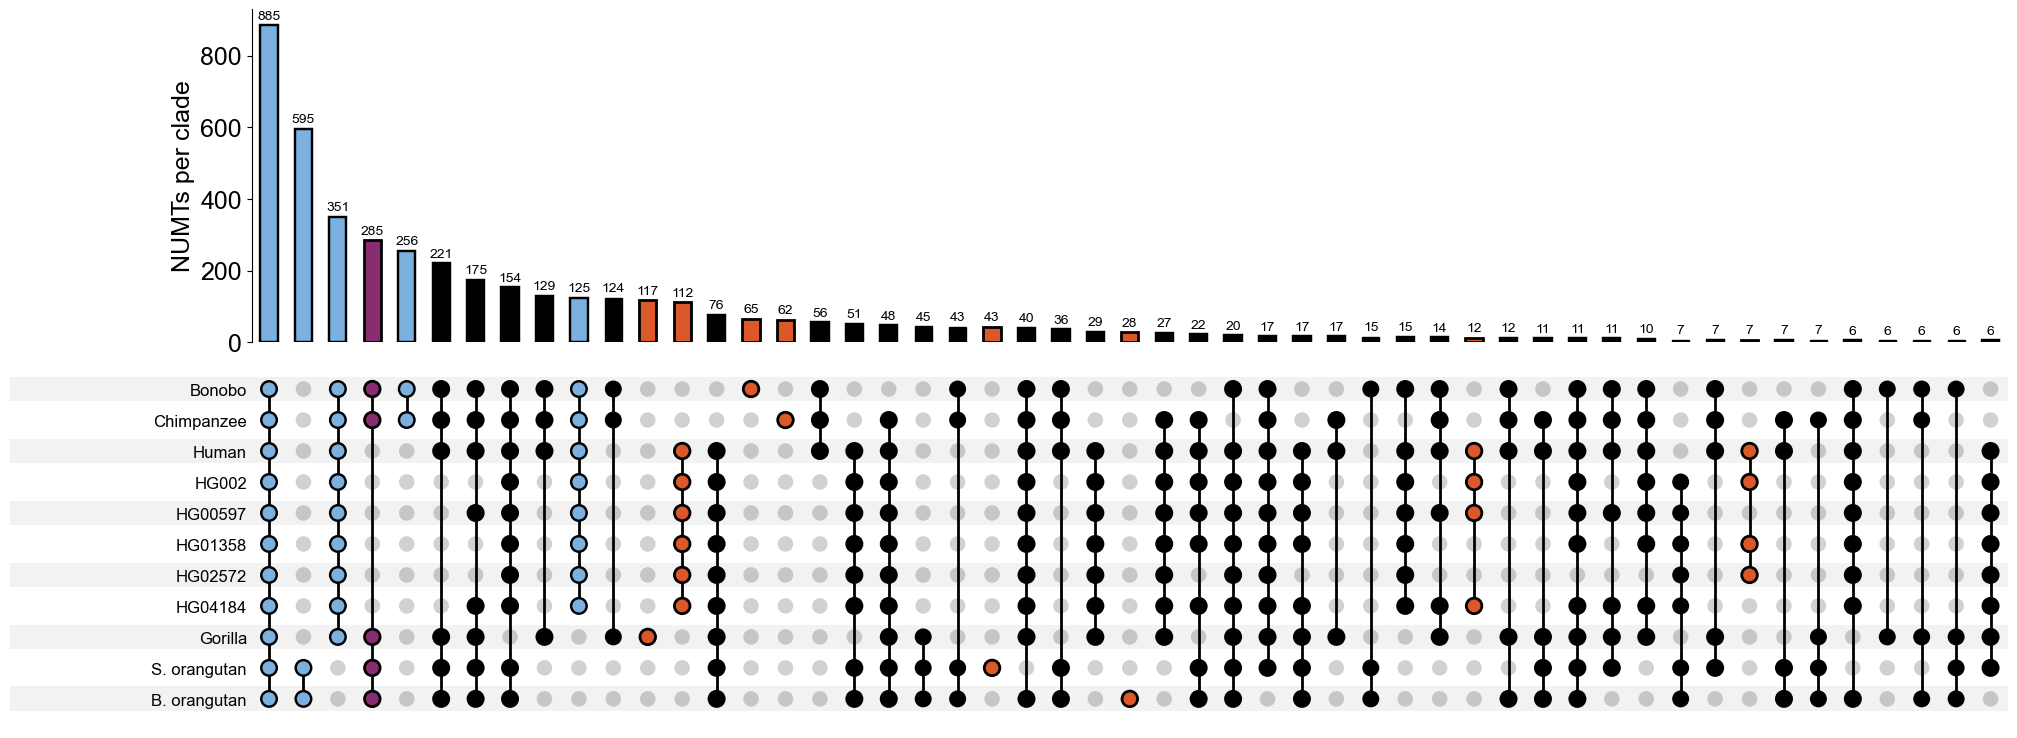

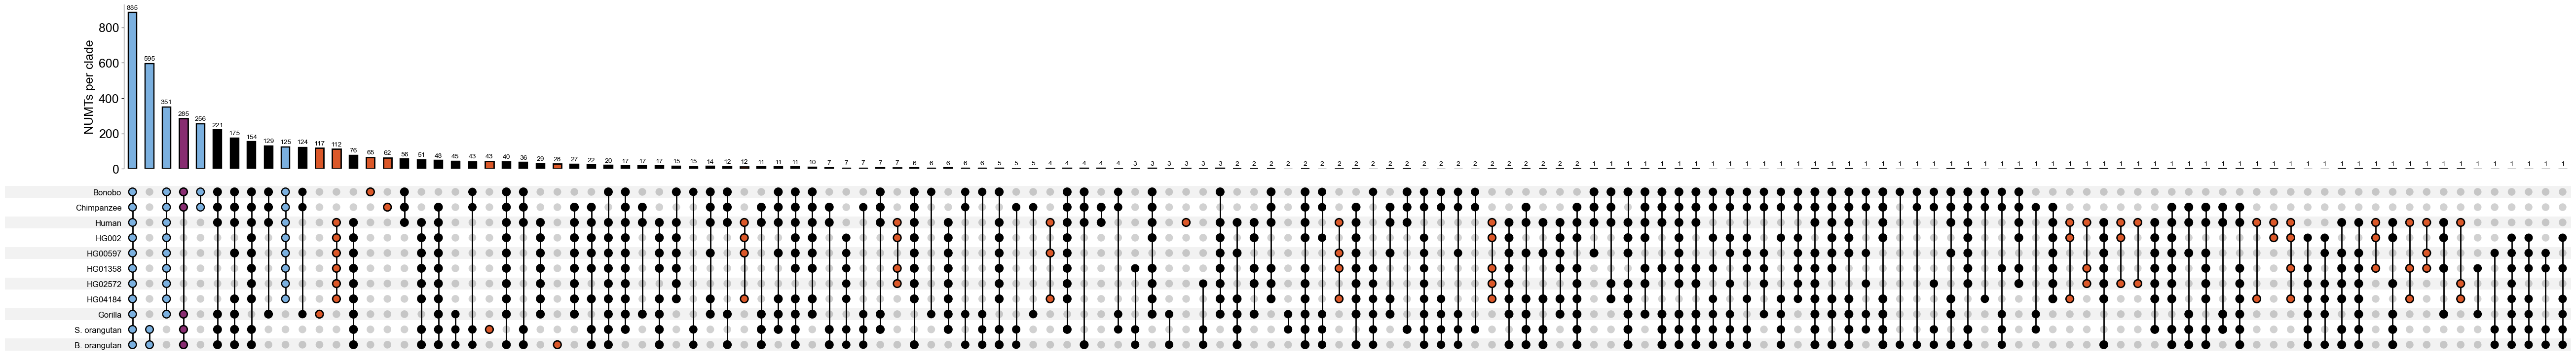

In [17]:
### Saswat's code for upset plots

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import FuncFormatter
import upsetplot as upsplt
import warnings

# Suppress pandas FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('future.no_silent_downcasting', True)

print('# Loaded libaries')

def saswat_generate_upset_plot(
        input_file_path,
        output_file_path,
        kmer_dissim_threshold,
        cardinality=False,
        min_subset_size = 1, # Set the minimum subset size
        max_subset_rank = 1000,
        show_counts=True,
        write=False
    ):
    print(f"[INFO] Reading input file: {input_file_path}")
    # Load and process the presence/absence matrix.
    presAbs_df = pd.read_table(input_file_path).drop('NUMT', axis=1).rename(columns={'Sorang': "S. orangutan", 'Borang': "B. orangutan"})
    print(f"[INFO] Input matrix shape: {presAbs_df.shape}")
    print(f"[INFO] kmer_dissim_threshold={kmer_dissim_threshold}, cardinality={cardinality}, min_subset_size={min_subset_size}, max_subset_rank={max_subset_rank}, write={write}")

    # Sort by species.
    presAbs_df = presAbs_df[[ "Bonobo", "Chimpanzee", "Human", "HG002", "HG00597", "HG01358", "HG02572", "HG04184", "Gorilla", "S. orangutan", "B. orangutan" ]]
    # presAbs_df = presAbs_df.rename(columns=lambda c: f"Human-{c}" if c.startswith("HG") else c)


    presAbsMatrixNormUpsetDict = {} #empty dictionary to store the indices of the presence/absence matrix.
    for column in presAbs_df.columns: #iterate through the columns.
        indices = [i for i, value in enumerate(presAbs_df[column]) if value == 1] #store the indices of the column where the value is 1.
        presAbsMatrixNormUpsetDict[column] = indices #store the indices in the dictionary.
        print(f"[INFO] Column '{column}': {len(indices)} present entries")

    # Import data into the upset plot.
    upsetData = upsplt.from_contents(presAbsMatrixNormUpsetDict) 
    print(f"[INFO] Raw upset data size: {len(upsetData)}")

    # Filter out subsets that are smaller than the minimum subset size.
    upsetData = upsetData[upsetData >= min_subset_size]
    print(f"[INFO] Filtered upset data size: {len(upsetData)}")

    # Plot with cardinality.
    if cardinality:
        upset = upsplt.UpSet(upsetData, sort_by="cardinality", sort_categories_by="-input", facecolor=CBPalette["Black"],
                             max_subset_rank = max_subset_rank, show_counts=show_counts, totals_plot_elements=4, intersection_plot_elements=10)
        print("[INFO] Created UpSet plot with cardinality sorting")
    # Plot by group/clade order.
    else:
        upset = upsplt.UpSet(upsetData, sort_categories_by="-input", facecolor=CBPalette["Black"], min_subset_size=min_subset_size,
                            max_subset_rank = max_subset_rank, show_counts=show_counts, totals_plot_elements=4, intersection_plot_elements=10)
        print("[INFO] Created UpSet plot with category ordering")
    
    # Optional color customization (excluding Siamang and including HPRC5).
    color_0 = CBPalette['Vermilion']
    color_1 = CBPalette['Black']
    color_2 = CBPalette['Mid blue']
    line_width = 1.75
    upset.style_subsets(facecolor=color_1, linewidth=line_width, edgecolor=color_1, present={'Human'} ) # all


    # colorhex = ["#004d71", "#8759a1", "#f75a78", "#ffa600"]
    samples = {"Bonobo", "Chimpanzee", "Human", "Gorilla", "S. orangutan", "B. orangutan", "HG002", "HG00597", "HG01358", "HG02572", "HG04184"}
    human_aliases = {"HG002", "HG00597", "HG01358", "HG02572", "HG04184"}

    # # Add prefix to humans
    # samples = {f"Human-{sample}" if sample.startswith("HG") else sample for sample in samples}
    # human_aliases = {f"Human-{alias}" for alias in human_aliases}

    # Expected clades.
    subset_configs = [
        ({"Bonobo", "Chimpanzee", "Human", "Gorilla", "S. orangutan", "B. orangutan"}, "BCHGO"),
        ({"Bonobo", "Chimpanzee", "Human", "Gorilla"}, "BCHG"),
        ({"Bonobo", "Chimpanzee", "Human"}, "BCH"),
        ({"Bonobo", "Chimpanzee"}, "BC"),
        ({"S. orangutan", "B. orangutan"}, "O"),
    ]
    for present_set, label in subset_configs:
        expanded_present_set = present_set | human_aliases if "Human" in present_set else present_set
        upset.style_subsets(
            facecolor=color_2,
            linewidth=line_width,
            edgecolor=color_1,
            absent=samples - expanded_present_set,
            present=expanded_present_set,
        )  # {label}

    ## Species-specific NUMTs
    # Color red if exactly one of the listed species is present and all others are absent
    focal_species = {"Bonobo", "Chimpanzee", "Gorilla", "S. orangutan", "B. orangutan"}
    for sp in focal_species:
        upset.style_subsets(
            facecolor=color_0,
            linewidth=2,
            edgecolor=color_1,
            present={sp},
            absent=samples - {sp},
        )

    # Color red if only Human assemblies are present
    absent_set = {"Bonobo", "Chimpanzee", "Gorilla", "S. orangutan", "B. orangutan"}
    upset.style_subsets(
        facecolor=color_0,
        linewidth=2,
        edgecolor=color_1,
        absent=absent_set,
    )

    # Color green if absent from all human clades but present in all others
    absent_humans = {"Human"} | human_aliases
    present_others = samples - absent_humans
    upset.style_subsets(
        facecolor=CBPalette['Dark purple'],
        linewidth=2,
        edgecolor=CBPalette['Black'],
        present=present_others,
        absent=absent_humans,
    )

    # Plot configurations
    # rcParams["font.size"] = 6.5
    rcParams['font.family'] = 'Arial'

    print("[INFO] Rendering plot")
    plot_result = upset.plot() #plot the result.

    # Set the font size of the y-axis tick labels.
    plot_result["matrix"].tick_params(axis='y', labelsize=12)

    plot_result["totals"].remove()
    # # The totals horizontal section.
    # plot_result["totals"].xaxis.set_major_formatter(FuncFormatter(comma_formatter))
    # plot_result["totals"].set_xlabel("NUMTs\nper species", fontsize=18, x=0.5) #set the x label
    # plot_result["totals"].tick_params(labelsize=15) #set the x tick labels

    # # Adjust the position of the totals plot to shift it more to the left.
    # plot_result["totals"].set_position([0.1, 0.11, 0.05, 0.275]) # x, y, width, height
    # plot_result["totals"].set_xlim(3000, 0)

    # if max_subset_rank < 100:
    #      # Adjust the position of the totals plot to shift it more to the left.
    #     plot_result["totals"].set_position([0.12, 0.11, 0.05, 0.275])
    #     plot_result["totals"].set_xlim(3000, 0)
    #     plot_result["totals"].set_xlabel("NUMTs\nper species", fontsize=15, x=0.65) #set the x label

    # plt.title(f"Number of NUMTs shared among species\n",fontsize=25)
    plt.ylabel("NUMTs per clade", fontsize=18) 
    plt.yticks(fontsize=18) 
    plt.grid(alpha=0.0, linestyle="--")

    if write:
        print(f"[INFO] Saving plot to: {output_file_path}")
        plt.savefig(output_file_path, format=output_file_path[-3:], transparent=True) #save the plot

        png_output_file_path = output_file_path.rsplit('.', 1)[0] + '.png'
        print(f"[INFO] Saving plot to: {png_output_file_path}")
        plt.savefig(png_output_file_path, format='png', transparent=False)
    

    print("[INFO] Plot complete")
    # plt.show()

print("# Defined main function.")

# Define the formatter function.
def comma_formatter(x, _pos):
    return '{:,.0f}'.format(x)

print("# Defined comma function.")

# Colorblind friendly palette.
CBPalette = {
    "Black": "#000000",
    "Orange": "#F4A637",
    "Light blue": "#B6DBFF",
    "Vermilion": "#DB5829",
    "Mid blue": "#7BB0DF",
    "Maroon": "#894B45",
    "Dark blue": "#1964B0",
    "Light purple": "#D2BBD7",
    "Light teal": "#00C992",
    "Purple": "#AE75A2",
    "Teal": "#008A69",
    "Dark purple": "#882D71",
    "Dark teal": "#386350",
    "Grey": "#DEDEDE",
    "Yellow": "#E9DC6D"
}

print("# Defined color palette.")

#######
# Run:
#######

flanks=500
kmer_dissim_threshold=0.5
file_in = f"hprc5.species_matrix_flanks{flanks}_{kmer_dissim_threshold}.tsv"

# Top 50 clades.
file_out = f"upset_plots.t2t_hprc5.cardinality_max50.pdf"
saswat_generate_upset_plot(
        input_file_path=file_in,
        output_file_path=file_out,
        kmer_dissim_threshold=kmer_dissim_threshold,
        min_subset_size=1,
        max_subset_rank = 50,
        show_counts=True,
        cardinality=True,
        write=True
    )

# All clades.
file_out = f"upset_plots.t2t_hprc5.cardinality.pdf"
saswat_generate_upset_plot(
    input_file_path=file_in,
    output_file_path=file_out,
    kmer_dissim_threshold=kmer_dissim_threshold,
    min_subset_size=1,
    max_subset_rank=1000,
    show_counts=True,
    cardinality=True,
    write=False
)





[INFO] Reading input file: hprc5.species_matrix_flanks500_0.5.tsv
[INFO] Input matrix shape: (4600, 11)
[INFO] kmer_dissim_threshold=0.5, cardinality=True, min_subset_size=1, max_subset_rank=1000, write=False
[INFO] Column 'Bonobo': 3168 present entries
[INFO] Column 'Chimpanzee': 3259 present entries
[INFO] Column 'Human': 2832 present entries
[INFO] Column 'HG002': 2110 present entries
[INFO] Column 'HG00597': 2304 present entries
[INFO] Column 'HG01358': 2109 present entries
[INFO] Column 'HG02572': 2041 present entries
[INFO] Column 'HG04184': 2320 present entries
[INFO] Column 'Gorilla': 2807 present entries
[INFO] Column 'S. orangutan': 2902 present entries
[INFO] Column 'B. orangutan': 2909 present entries
[INFO] Raw upset data size: 4600
[INFO] Filtered upset data size: 4600
[INFO] Created UpSet plot with cardinality sorting
[INFO] Rendering plot
[INFO] Plot complete


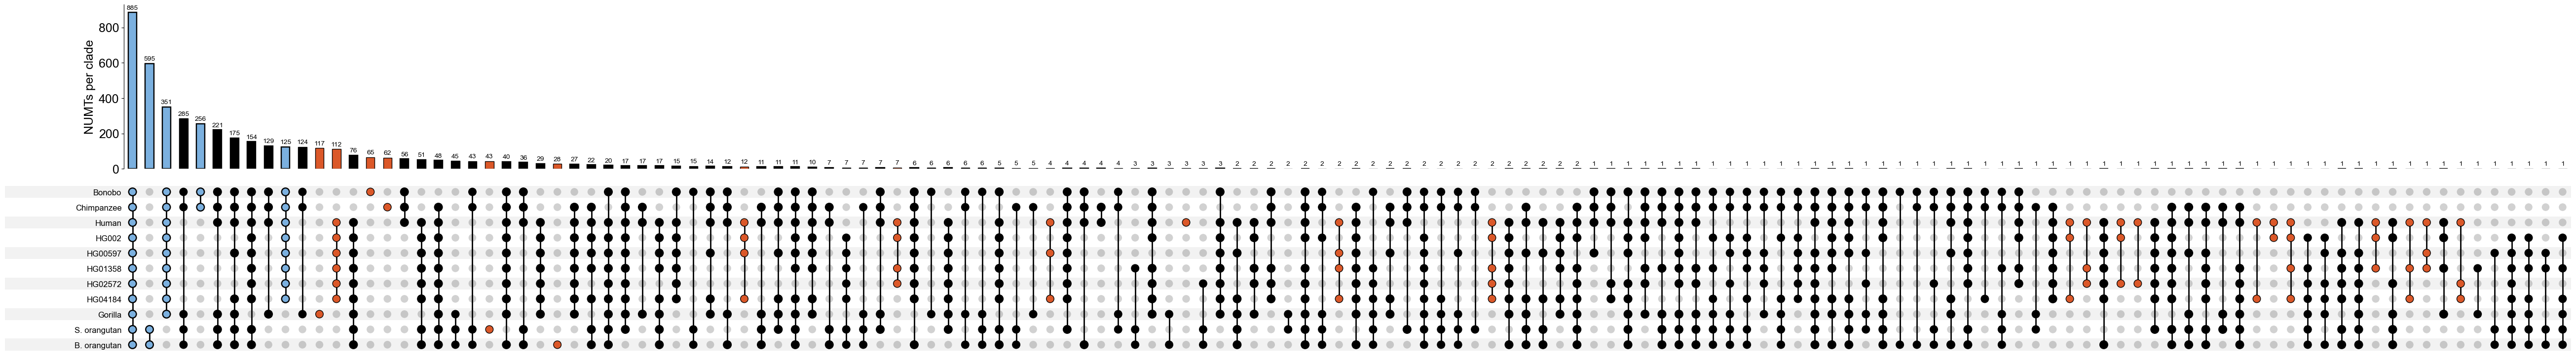

In [12]:
# All clades.
file_out = f"upset_plots.t2t_hprc5.cardinality.pdf"
saswat_generate_upset_plot(
    input_file_path=file_in,
    output_file_path=file_out,
    kmer_dissim_threshold=kmer_dissim_threshold,
    min_subset_size=1,
    max_subset_rank=1000,
    cardinality=True,
    write=False
)


[INFO] Reading input file: hprc5.species_matrix_flanks500_0.5.tsv
[INFO] Input matrix shape: (4600, 11)
[INFO] kmer_dissim_threshold=0.5, cardinality=False, min_subset_size=1, max_subset_rank=1000, write=False
[INFO] Column 'Bonobo': 3168 present entries
[INFO] Column 'Chimpanzee': 3259 present entries
[INFO] Column 'Human': 2832 present entries
[INFO] Column 'HG002': 2110 present entries
[INFO] Column 'HG00597': 2304 present entries
[INFO] Column 'HG01358': 2109 present entries
[INFO] Column 'HG02572': 2041 present entries
[INFO] Column 'HG04184': 2320 present entries
[INFO] Column 'Gorilla': 2807 present entries
[INFO] Column 'S. orangutan': 2902 present entries
[INFO] Column 'B. orangutan': 2909 present entries
[INFO] Raw upset data size: 4600
[INFO] Filtered upset data size: 4600
[INFO] Created UpSet plot with category ordering
[INFO] Rendering plot
[INFO] Plot complete


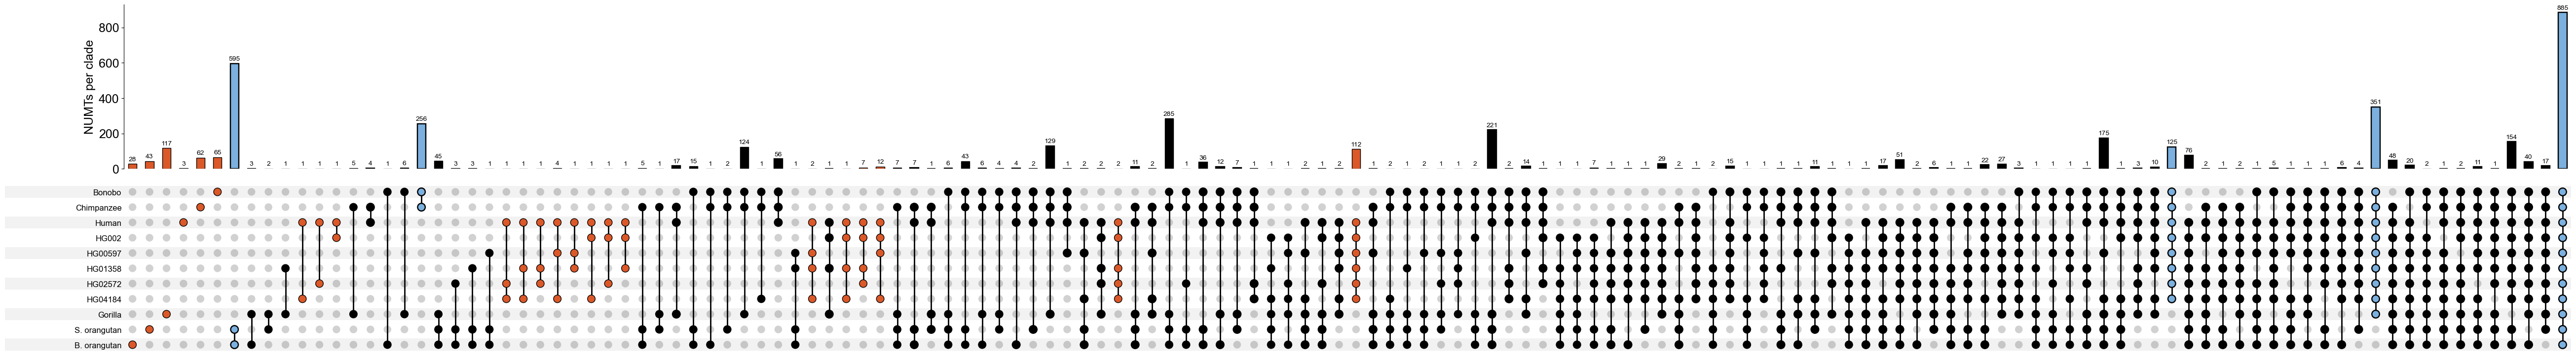

In [13]:
# All clades (sorted).
file_out = f"upset_plots.t2t_hprc5.pdf"
saswat_generate_upset_plot(
    input_file_path=file_in,
    output_file_path=file_out,
    kmer_dissim_threshold=kmer_dissim_threshold,
    min_subset_size=1,
    max_subset_rank=1000,
    cardinality=False,
    write=False
)